# L=32 XY — direct raw-PCA versus frozen-ResNet comparison

Both representations use the same 4.1 million seed–temperature–bin observations, the same balanced PCA-fit indices, the same spectral landmark indices, and the same diagnostic indices.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_mutual_info_score

OUT=Path('/home/lledson/senior-thesis/data/processed/xy32_broad/matched_all_bins')
raw=json.loads((OUT/'raw_spin_summary.json').read_text())
res=json.loads((OUT/'resnet18_summary.json').read_text())
raw_diag=json.loads((OUT/'raw_spin_cluster_diagnostics.json').read_text())
res_diag=json.loads((OUT/'resnet18_cluster_diagnostics.json').read_text())
raw_labels=np.load(OUT/'raw_spin_pc40_cluster_labels.npy',mmap_mode='r')
res_labels=np.load(OUT/'resnet18_pc40_cluster_labels.npy',mmap_mode='r')
ami=adjusted_mutual_info_score(raw_labels,res_labels)
comparison=pd.DataFrame({
    'representation':['Raw cos/sin PCA','Frozen ResNet-18'],
    'PCs for 90% variance':[raw['n90'],res['n90']],
    'Clustering features':[raw_diag['clustering_features'],res_diag['clustering_features']],
    '40-PC silhouette':[raw_diag['silhouette'],res_diag['silhouette']],
    'Low-T high-cluster fraction':[raw_diag['low_endpoint_high_cluster_fraction'],res_diag['low_endpoint_high_cluster_fraction']],
    'High-T high-cluster fraction':[raw_diag['high_endpoint_high_cluster_fraction'],res_diag['high_endpoint_high_cluster_fraction']],
})
comparison['Cross-representation cluster AMI']=ami
comparison.to_csv(OUT/'xy32_representation_comparison.csv',index=False)
comparison


,representation,PCs for 90% variance,Clustering features,40-PC silhouette,Low-T high-cluster fraction,High-T high-cluster fraction,Cross-representation cluster AMI
0,Raw cos/sin PCA,1158,PC1–PC2 radius + PCs 3–40,0.238057,0.00000,1.00000,0.091063
1,Frozen ResNet-18,43,PCs 1–40,0.181734,0.34559,0.99665,0.091063


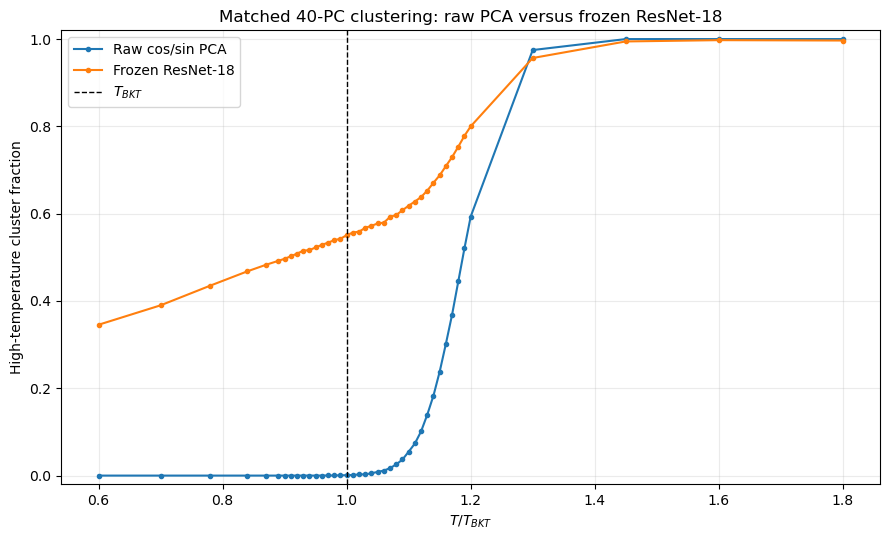

In [2]:
raw_pop=pd.read_csv(OUT/'raw_spin_cluster_populations.csv')
res_pop=pd.read_csv(OUT/'resnet18_cluster_populations.csv')
fig,ax=plt.subplots(figsize=(9,5.5))
for frame,label,color in ((raw_pop,'Raw cos/sin PCA','tab:blue'),(res_pop,'Frozen ResNet-18','tab:orange')):
    high=frame[frame.cluster==1]
    ax.plot(high.T_over_TBKT,high.fraction,'o-',ms=3,label=label,color=color)
ax.axvline(1,color='black',ls='--',lw=1,label=r'$T_{BKT}$')
ax.set(xlabel=r'$T/T_{BKT}$',ylabel='High-temperature cluster fraction',title='Matched 40-PC clustering: raw PCA versus frozen ResNet-18',ylim=(-.02,1.02))
ax.grid(alpha=.25); ax.legend(); fig.tight_layout(); fig.savefig(OUT/'xy32_raw_vs_resnet_cluster_comparison.png',dpi=220); plt.show(); plt.close(fig)


## Scientific interpretation

Use the table and matched population curves above to judge whether ResNet adds structure absent from raw PCA. Both clustering models use 40 PCs and the same 410,000 fit observations. Raw PC1–PC2 are represented by their radius to respect the XY ring, while ResNet PCs enter directly. A larger silhouette indicates more internally coherent separation; cross-representation AMI measures whether the two methods group the same observations.